In [782]:
import pandas as pd
import numpy as np
import spacy

from natasha import (
    Segmenter,
    MorphVocab,
    
    NewsEmbedding,
    NewsMorphTagger,
    NewsSyntaxParser,
    NewsNERTagger,
    
    PER,
    NamesExtractor,

    Doc
)

import re
import matplotlib.pyplot as plt

In [193]:
dataset = pd.read_csv("ru_cefr_short.csv")

In [194]:
dataset

,fragment,textbook-assigned cefr level
0,"Весной, летом и осенью почти каждую субботу он...",1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1
2,На каждой двери красные плакаты и красные фона...,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1
...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6
7320,Mapillary использует программное обеспечение д...,6


In [195]:
dataset.loc[dataset.duplicated(), :]

,fragment,textbook-assigned cefr level
797,Она живёт в маленькой квартире вместе с матерь...,2
805,"Музыкой начала заниматься, когда мне было 5 ле...",2
814,"Музыкой начала заниматься, когда мне было 5 ле...",2
817,До мая 2007 года об этой музыкальной группе ни...,2
818,До мая 2007 года об этой музыкальной группе ни...,2
...,...,...
6585,В 1952 году Шагал женится на Ваве — Валентине ...,5
6628,В мировой эпидемии ожирения виноват не только ...,5
6731,"И честнее было бы, чтобы герой ролика плыл по ...",5
6876,"Теперь же его знает каждый ребёнок»,— говорит ...",5


In [199]:
dataset = dataset.loc[~dataset.duplicated(), :]
dataset

,fragment,textbook-assigned cefr level
0,"Весной, летом и осенью почти каждую субботу он...",1
1,"Все говорят, что мама хорошая хозяйка. А ещё н...",1
2,На каждой двери красные плакаты и красные фона...,1
3,"Я считаю деньги, в час обедаю в кафе, а потом ...",1
4,Магазин «Чёрный квадрат» открывается в 9 часов...,1
...,...,...
7317,Утечка мозгов стала ключевым трендом междунаро...,6
7318,"По оценкам менеджеров «Промы», такая ситуация ...",6
7319,"Но это не мы, а техно-мемы заполоняют мир благ...",6
7320,Mapillary использует программное обеспечение д...,6


In [201]:
dataset["textbook-assigned cefr level"][50]

1

In [203]:
dataset["fragment"][50]

'В спальне мы отдыхаем и читаем вечером. В детской стоит кровать, стол и стул, маленький шкаф, книжные полки и музыкальный центр.'

In [205]:
dataset_2 = pd.read_csv("aggregated_results_by_ds__pool_37806285__2023_02_18.tsv", sep = "\t")
dataset_2 = dataset_2.drop("Unnamed: 3", axis = 1)
dataset_2

,INPUT:text,OUTPUT:category,CONFIDENCE:category
0,"Разглядывая их под микроскопом , мы увидим при...",[4],100.00%
1,"Иногда талантливые люди , не найдя себя в наук...",[4],100.00%
2,Кандидаты в депутаты от общественных организац...,[6],100.00%
3,"Главное , чтобы "" социальные лифты "" не остана...",[6],100.00%
4,Франция признает российских студентов и не при...,[2],100.00%
...,...,...,...
595,Характеристики солитонов при этом постоянно ме...,[5],100.00%
596,"Телефонами мы пользуемся помногу , в течение д...",[3],100.00%
597,Конкурентная оплата для преподавателя вуза в М...,[6],100.00%
598,"Главное , чтобы пункт назначения всегда был в ...",[5],100.00%


In [207]:
segmenter = Segmenter()
morph_vocab = MorphVocab()

emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)
syntax_parser = NewsSyntaxParser(emb)
ner_tagger = NewsNERTagger(emb)
names_extractor = NamesExtractor(morph_vocab)

In [208]:
dataset_np = np.array(dataset["fragment"])

In [209]:
dataset_np[6078]

'После этого начался последний штурм центральной части города, где находилась Имперская канцелярия. Всю ночь с 1 на 2 мая продолжались бои за канцелярию.'

In [210]:
text = dataset_np[6078]
doc = Doc(text)

### Segmentation

In [212]:
doc.segment(segmenter)

In [217]:
doc.tokens

[DocToken(stop=5, text='После'),
 DocToken(start=6, stop=11, text='этого'),
 DocToken(start=12, stop=19, text='начался'),
 DocToken(start=20, stop=29, text='последний'),
 DocToken(start=30, stop=35, text='штурм'),
 DocToken(start=36, stop=47, text='центральной'),
 DocToken(start=48, stop=53, text='части'),
 DocToken(start=54, stop=60, text='города'),
 DocToken(start=60, stop=61, text=','),
 DocToken(start=62, stop=65, text='где'),
 DocToken(start=66, stop=76, text='находилась'),
 DocToken(start=77, stop=86, text='Имперская'),
 DocToken(start=87, stop=97, text='канцелярия'),
 DocToken(start=97, stop=98, text='.'),
 DocToken(start=99, stop=102, text='Всю'),
 DocToken(start=103, stop=107, text='ночь'),
 DocToken(start=108, stop=109, text='с'),
 DocToken(start=110, stop=111, text='1'),
 DocToken(start=112, stop=114, text='на'),
 DocToken(start=115, stop=116, text='2'),
 DocToken(start=117, stop=120, text='мая'),
 DocToken(start=121, stop=133, text='продолжались'),
 DocToken(start=134, stop

In [220]:
doc.sents

[DocSent(stop=98, text='После этого начался последний штурм центральной ч..., tokens=[...]),
 DocSent(start=99, stop=152, text='Всю ночь с 1 на 2 мая продолжались бои за канцеля..., tokens=[...])]

### Morphology

In [223]:
doc.tag_morph(morph_tagger)

In [225]:
doc.tokens

[DocToken(stop=5, text='После', pos='ADP'),
 DocToken(start=6, stop=11, text='этого', pos='PRON', feats=<Inan,Gen,Neut,Sing>),
 DocToken(start=12, stop=19, text='начался', pos='VERB', feats=<Perf,Masc,Ind,Sing,Past,Fin,Mid>),
 DocToken(start=20, stop=29, text='последний', pos='ADJ', feats=<Nom,Pos,Masc,Sing>),
 DocToken(start=30, stop=35, text='штурм', pos='NOUN', feats=<Inan,Nom,Masc,Sing>),
 DocToken(start=36, stop=47, text='центральной', pos='ADJ', feats=<Gen,Pos,Fem,Sing>),
 DocToken(start=48, stop=53, text='части', pos='NOUN', feats=<Inan,Gen,Fem,Sing>),
 DocToken(start=54, stop=60, text='города', pos='NOUN', feats=<Inan,Gen,Masc,Sing>),
 DocToken(start=60, stop=61, text=',', pos='PUNCT'),
 DocToken(start=62, stop=65, text='где', pos='ADV', feats=<Pos>),
 DocToken(start=66, stop=76, text='находилась', pos='VERB', feats=<Imp,Fem,Ind,Sing,Past,Fin,Mid>),
 DocToken(start=77, stop=86, text='Имперская', pos='ADJ', feats=<Nom,Pos,Fem,Sing>),
 DocToken(start=87, stop=97, text='канцелярия

In [227]:
doc.sents[0].morph.print()

               После ADP
               этого PRON|Animacy=Inan|Case=Gen|Gender=Neut|Number=Sing
             начался VERB|Aspect=Perf|Gender=Masc|Mood=Ind|Number=Sing|Tense=Past|VerbForm=Fin|Voice=Mid
           последний ADJ|Case=Nom|Degree=Pos|Gender=Masc|Number=Sing
               штурм NOUN|Animacy=Inan|Case=Nom|Gender=Masc|Number=Sing
         центральной ADJ|Case=Gen|Degree=Pos|Gender=Fem|Number=Sing
               части NOUN|Animacy=Inan|Case=Gen|Gender=Fem|Number=Sing
              города NOUN|Animacy=Inan|Case=Gen|Gender=Masc|Number=Sing
                   , PUNCT
                 где ADV|Degree=Pos
          находилась VERB|Aspect=Imp|Gender=Fem|Mood=Ind|Number=Sing|Tense=Past|VerbForm=Fin|Voice=Mid
           Имперская ADJ|Case=Nom|Degree=Pos|Gender=Fem|Number=Sing
          канцелярия NOUN|Animacy=Inan|Case=Nom|Gender=Fem|Number=Sing
                   . PUNCT


### Lemmatization

In [230]:
for token in doc.tokens:
     token.lemmatize(morph_vocab)

In [232]:
print(doc.tokens[:5])
{_.text: _.lemma for _ in doc.tokens}

[DocToken(stop=5, text='После', pos='ADP', lemma='после'), DocToken(start=6, stop=11, text='этого', pos='PRON', feats=<Inan,Gen,Neut,Sing>, lemma='это'), DocToken(start=12, stop=19, text='начался', pos='VERB', feats=<Perf,Masc,Ind,Sing,Past,Fin,Mid>, lemma='начаться'), DocToken(start=20, stop=29, text='последний', pos='ADJ', feats=<Nom,Pos,Masc,Sing>, lemma='последний'), DocToken(start=30, stop=35, text='штурм', pos='NOUN', feats=<Inan,Nom,Masc,Sing>, lemma='штурм')]


{'После': 'после',
 'этого': 'это',
 'начался': 'начаться',
 'последний': 'последний',
 'штурм': 'штурм',
 'центральной': 'центральный',
 'части': 'часть',
 'города': 'город',
 ',': ',',
 'где': 'где',
 'находилась': 'находиться',
 'Имперская': 'имперский',
 'канцелярия': 'канцелярия',
 '.': '.',
 'Всю': 'весь',
 'ночь': 'ночь',
 'с': 'с',
 '1': '1',
 'на': 'на',
 '2': '2',
 'мая': 'май',
 'продолжались': 'продолжаться',
 'бои': 'бой',
 'за': 'за',
 'канцелярию': 'канцелярия'}

### Syntax parser

In [235]:
doc.parse_syntax(syntax_parser)
print(doc.tokens[:5])
doc.sents[0].syntax.print()

[DocToken(stop=5, text='После', id='1_1', head_id='1_2', rel='case', pos='ADP', lemma='после'), DocToken(start=6, stop=11, text='этого', id='1_2', head_id='1_3', rel='obl', pos='PRON', feats=<Inan,Gen,Neut,Sing>, lemma='это'), DocToken(start=12, stop=19, text='начался', id='1_3', head_id='1_0', rel='root', pos='VERB', feats=<Perf,Masc,Ind,Sing,Past,Fin,Mid>, lemma='начаться'), DocToken(start=20, stop=29, text='последний', id='1_4', head_id='1_5', rel='amod', pos='ADJ', feats=<Nom,Pos,Masc,Sing>, lemma='последний'), DocToken(start=30, stop=35, text='штурм', id='1_5', head_id='1_3', rel='nsubj', pos='NOUN', feats=<Inan,Nom,Masc,Sing>, lemma='штурм')]
          ┌► После       case
        ┌►└─ этого       obl
┌─────┌─└─── начался     
│     │   ┌► последний   amod
│   ┌─└──►└─ штурм       nsubj
│   │     ┌► центральной amod
│ ┌─└──►┌─└─ части       nmod
│ │     └──► города      nmod
│ │     ┌──► ,           punct
│ │     │ ┌► где         advmod
│ └──►┌─└─└─ находилась  acl:relcl
│     │  

### NER

In [238]:
doc.tag_ner(ner_tagger)
print(doc.spans[:5])
doc.ner.print()

[DocSpan(start=77, stop=97, type='LOC', text='Имперская канцелярия', tokens=[...])]
После этого начался последний штурм центральной части города, где 
находилась Имперская канцелярия. Всю ночь с 1 на 2 мая продолжались 
           LOC─────────────────                                     
бои за канцелярию.


## Features

In [241]:
feats_table = pd.DataFrame()

In [243]:
feats_table["length"] = dataset["fragment"].map(lambda x: len(x.split()))

In [245]:
print(f'Среднее количество токенов в тексте: {feats_table["length"].mean()}')
print(f'Минимальное количество токенов в тексте: {feats_table["length"].min()}')
print(f'Максимальное количество токенов втексте: {feats_table["length"].max()}')

Среднее количество токенов в тексте: 24.061888352860098
Минимальное количество токенов в тексте: 15
Максимальное количество токенов втексте: 40


In [247]:
feats_table["text"] = dataset["fragment"]
feats_table["complexity"] = dataset["textbook-assigned cefr level"]

In [249]:
sentence_test = doc.sents[0].text
sentence_test

'После этого начался последний штурм центральной части города, где находилась Имперская канцелярия.'

In [251]:
doc.sents

[DocSent(stop=98, text='После этого начался последний штурм центральной ч..., tokens=[...], spans=[...]),
 DocSent(start=99, stop=152, text='Всю ночь с 1 на 2 мая продолжались бои за канцеля..., tokens=[...])]

In [253]:
len(doc.sents[0].tokens[2].text)

7

In [255]:
from collections import Counter

In [510]:
def compute_sentence_info(sentences):
    doc_sent_info = {}
    sent_n = 1
    for sentence in sentences:
        df_tokens = {}
        df_heads = {}
        df_lengths = {}
        for token in sentence.tokens:
            df_tokens[token.id] = [token.text, token.lemma, token.head_id, token.rel, token.pos, len(token.text)]
            if token.head_id not in df_heads:
                df_heads[token.head_id] = 1
            else:
                df_heads[token.head_id] += 1

        df_heads = {x:y for x,y in df_heads.items() if not x.endswith('_0')}
        doc_sent_info[sent_n] = {"df_tokens" : df_tokens, "df_heads": df_heads}
        df_real_tokens = {key : token for key, token in doc_sent_info[sent_n]["df_tokens"].items() if not token[4] == ('PUNCT' or "SYM" or "X")} # без знаков пунктуации
        doc_sent_info[sent_n]["df_real_tokens"] = df_real_tokens
        
        for token in sentence.tokens:
            head_id = doc_sent_info[sent_n]["df_tokens"][token.id][2]
            len_sent = 1
            tokens_done = []
            while not head_id.endswith("_0"):
                new_head_id = doc_sent_info[sent_n]["df_tokens"][head_id][2]
                if new_head_id in tokens_done:
                    doc_sent_info[sent_n]["df_heads"][new_head_id] -= 1 
                    new_head_id = str(sent_n) + "_0"
                    doc_sent_info[sent_n]["df_tokens"][head_id][2] = new_head_id
                    break
                tokens_done.append(head_id)
                head_id = new_head_id
                len_sent += 1
            df_lengths[token.id] = len_sent
        doc_sent_info[sent_n]["df_lengths"] = df_lengths

        double_child_n = Counter(doc_sent_info[sent_n]["df_heads"].values())[2]
        inner_vertices_n = len(doc_sent_info[sent_n]["df_heads"])
        vertices_n = len(doc_sent_info[sent_n]["df_real_tokens"])
        if len(doc_sent_info[sent_n]["df_heads"]) == 0:
            tree_depth = 0
        else:
            tree_depth = max(doc_sent_info[sent_n]["df_heads"].values())
        leaves_n = len(doc_sent_info[sent_n]["df_real_tokens"]) - len(doc_sent_info[sent_n]["df_heads"])
        
        dep_relations = np.array(list(doc_sent_info[sent_n]["df_real_tokens"].values()))[:,3]
        dep_relations = np.array([i.split(":")[0] for i in dep_relations])

        deps_counter = Counter(dep_relations)
        amod_n = deps_counter['amod']
        compound_n = deps_counter['compound']
        conj_n = deps_counter['conj']
        det_n = deps_counter['det']
        nmod_n = deps_counter['nmod']
        nsubj_n = deps_counter['nsubj']

        unique_deps = len(deps_counter)
    
        real_tokens_keys = np.array(list(doc_sent_info[sent_n]["df_real_tokens"].keys()))
        tokens_keys = np.array(list(doc_sent_info[sent_n]["df_tokens"].keys()))
        
        df_linear_distance = {}
        for token_id in doc_sent_info[sent_n]["df_real_tokens"]:
            token_head_id = doc_sent_info[sent_n]["df_real_tokens"][token_id][2]
            if token_head_id.endswith("_0"):
                lin_dist = 0
                pass
            else:
                if doc_sent_info[sent_n]["df_tokens"][token_head_id][4] == ('PUNCT' or "SYM" or "X"):
                    lin_dist = np.abs(np.where(real_tokens_keys == token_id)[0][0] - np.where(tokens_keys == token_head_id)[0][0])
                else:
                    lin_dist = np.abs(np.where(real_tokens_keys == token_id)[0][0] - np.where(real_tokens_keys == token_head_id)[0][0])
            df_linear_distance[token_id] = lin_dist
        
        mean_linear_distance = np.array(list(df_linear_distance.values())).mean()
        
        sw_array = np.array(list(df_real_tokens.values()))[:,5].astype(np.int_)
        asw = sw_array.mean()

        sentence_pos_array = np.array(list(df_real_tokens.values()))[:,4]

        pos_counter = Counter(sentence_pos_array)
        adj_n = pos_counter['ADJ']
        adp_n = pos_counter['ADP']
        adv_n = pos_counter['ADV']
        aux_n = pos_counter['AUX']
        cconj_n = pos_counter['CCONJ']
        det_pos_n = pos_counter['DET']
        intj_n = pos_counter['INTJ']
        noun_n = pos_counter['NOUN']
        num_n = pos_counter['NUM']
        part_n = pos_counter['PART']
        pron_n = pos_counter['PRON']
        propn_n = pos_counter['PROPN']
        sconj_n = pos_counter['SCONJ']
        verb_n = pos_counter['VERB']
        unique_pos = len(pos_counter)
        
        doc_sent_info[sent_n]["double_child_n"] = double_child_n
        doc_sent_info[sent_n]["inner_vertices_n"] = inner_vertices_n
        doc_sent_info[sent_n]["vertices_n"] = vertices_n
        doc_sent_info[sent_n]["tree_depth"] = tree_depth
        doc_sent_info[sent_n]["leaves_n"] = leaves_n
        doc_sent_info[sent_n]["amod_n"] = amod_n
        doc_sent_info[sent_n]["compound_n"] = compound_n
        doc_sent_info[sent_n]["conj_n"] = conj_n
        doc_sent_info[sent_n]["det_n"] = det_n
        doc_sent_info[sent_n]["nmod_n"] = nmod_n
        doc_sent_info[sent_n]["nsubj_n"] = nsubj_n
        doc_sent_info[sent_n]["mean_linear_distance"] = mean_linear_distance
        doc_sent_info[sent_n]["unique_deps"] = unique_deps

        doc_sent_info[sent_n]["asw"] = asw

        doc_sent_info[sent_n]["adj_n"] = adj_n / vertices_n
        doc_sent_info[sent_n]["adp_n"] = adp_n / vertices_n
        doc_sent_info[sent_n]["adv_n"] = adv_n / vertices_n
        doc_sent_info[sent_n]["aux_n"] = aux_n / vertices_n
        doc_sent_info[sent_n]["cconj_n"] = cconj_n / vertices_n
        doc_sent_info[sent_n]["det_pos_n"] = det_pos_n / vertices_n
        doc_sent_info[sent_n]["intj_n"] = intj_n / vertices_n
        doc_sent_info[sent_n]["noun_n"] = noun_n / vertices_n
        doc_sent_info[sent_n]["num_n"] = num_n / vertices_n
        doc_sent_info[sent_n]["part_n"] = part_n / vertices_n
        doc_sent_info[sent_n]["pron_n"] = pron_n / vertices_n
        doc_sent_info[sent_n]["propn_n"] = propn_n / vertices_n
        doc_sent_info[sent_n]["sconj_n"] = sconj_n / vertices_n
        doc_sent_info[sent_n]["verb_n"] = verb_n / vertices_n
        doc_sent_info[sent_n]["unique_pos"] = unique_pos
        
        sent_n +=1
    return doc_sent_info

In [512]:
compute_sentence_info(doc.sents)

{1: {'df_tokens': {'1_1': ['После', 'после', '1_2', 'case', 'ADP', 5],
   '1_2': ['этого', 'это', '1_3', 'obl', 'PRON', 5],
   '1_3': ['начался', 'начаться', '1_0', 'root', 'VERB', 7],
   '1_4': ['последний', 'последний', '1_5', 'amod', 'ADJ', 9],
   '1_5': ['штурм', 'штурм', '1_3', 'nsubj', 'NOUN', 5],
   '1_6': ['центральной', 'центральный', '1_7', 'amod', 'ADJ', 11],
   '1_7': ['части', 'часть', '1_5', 'nmod', 'NOUN', 5],
   '1_8': ['города', 'город', '1_7', 'nmod', 'NOUN', 6],
   '1_9': [',', ',', '1_11', 'punct', 'PUNCT', 1],
   '1_10': ['где', 'где', '1_11', 'advmod', 'ADV', 3],
   '1_11': ['находилась', 'находиться', '1_7', 'acl:relcl', 'VERB', 10],
   '1_12': ['Имперская', 'имперский', '1_13', 'amod', 'ADJ', 9],
   '1_13': ['канцелярия', 'канцелярия', '1_11', 'nsubj', 'NOUN', 10],
   '1_14': ['.', '.', '1_3', 'punct', 'PUNCT', 1]},
  'df_heads': {'1_2': 1, '1_3': 3, '1_5': 2, '1_7': 3, '1_11': 3, '1_13': 1},
  'df_real_tokens': {'1_1': ['После', 'после', '1_2', 'case', 'ADP', 5

In [578]:
def compute_sentence_features(sentence_info):
    double_child = []
    inner_vertices = []
    vertices = []
    tree_depth = []
    amod = []
    compound = []
    conj = []
    det = []
    nmod = []
    nsubj = []
    leaves = []
    mean_linear_distance = []
    unique_deps = []
    asw = []

    adj = []
    adp = []
    adv = []
    aux = []
    cconj = []
    det_pos = []
    intj = []
    noun = []
    num = []
    part = []
    pron = []
    propn = []
    sconj = []
    verb = []
    unique_pos = []
    
    for d in sentence_info.values():
        double_child.append(d["double_child_n"])
        inner_vertices.append(d["inner_vertices_n"])
        vertices.append(d["vertices_n"])
        tree_depth.append(d["tree_depth"])
        amod.append(d["amod_n"])
        compound.append(d["compound_n"])
        conj.append(d["conj_n"])
        det.append(d["det_n"])
        nmod.append(d["nmod_n"])
        nsubj.append(d["nsubj_n"])
        leaves.append(d["leaves_n"])
        mean_linear_distance.append(d["mean_linear_distance"])
        unique_deps.append(d["unique_deps"])

        adj.append(d["adj_n"])
        adp.append(d["adp_n"])
        adv.append(d["adv_n"])
        aux.append(d["aux_n"])
        cconj.append(d["cconj_n"])
        det_pos.append(d["det_pos_n"])
        intj.append(d["intj_n"])
        noun.append(d["noun_n"])
        num.append(d["num_n"])
        part.append(d["part_n"])
        pron.append(d["pron_n"])
        propn.append(d["propn_n"])
        sconj.append(d["sconj_n"])
        verb.append(d["verb_n"])
        unique_pos.append(d["unique_pos"])

        asw.append(d["asw"])

    sum_length = np.sum(vertices)
    avg_double_child = np.mean(double_child)
    avg_inner_vertices = np.mean(inner_vertices)
    avg_vertices = np.mean(vertices)
    avg_tree_depth = np.mean(tree_depth)
    avg_amod = np.mean(amod)
    avg_compound = np.mean(compound)
    avg_conj = np.mean(conj)
    avg_det = np.mean(det)
    avg_nmod = np.mean(nmod)
    avg_nsubj = np.mean(nsubj)
    avg_unique_deps = np.mean(unique_deps)
    max_leaves = np.max(leaves)
    max_inner_vertices = np.max(inner_vertices)
    max_vertices = np.max(vertices)
    max_unique_deps = np.max(unique_deps)
    median_nmod = np.median(nmod)
    median_inner_vertices = np.median(inner_vertices)
    median_vertices = np.median(vertices)
    std_leaves = np.std(leaves)
    std_vertices = np.std(vertices)
    std_conj = np.std(conj)
    std_det = np.std(det)
    std_mean_linear_distance = np.std(mean_linear_distance)

    avg_adj = np.mean(adj)
    avg_adp = np.mean(adp)
    avg_adv = np.mean(adv)
    avg_aux = np.mean(aux)
    avg_cconj = np.mean(cconj)
    avg_det_pos = np.mean(det_pos)
    avg_intj = np.mean(intj)
    avg_noun = np.mean(noun)
    avg_num = np.mean(num)
    avg_part = np.mean(part)
    avg_pron = np.mean(pron)
    avg_propn = np.mean(propn)
    avg_sconj = np.mean(sconj)
    avg_verb = np.mean(verb)
    avg_unique_pos = np.mean(unique_pos)
    max_unique_pos = np.max(unique_pos)

    avg_asw = np.mean(asw)

    return {
        "avg_double_child": avg_double_child,
        "avg_inner_vertices": avg_inner_vertices,
        "avg_vertices": avg_vertices,
        "avg_tree_depth": avg_tree_depth,
        "avg_amod": avg_amod,
        "avg_compound": avg_compound,
        "avg_conj": avg_conj,
        "avg_det": avg_det,
        "avg_nmod": avg_nmod,
        "avg_nsubj": avg_nsubj,
        "avg_unique_deps": avg_unique_deps,
        "max_leaves": max_leaves,
        "max_inner_vertices": max_inner_vertices,
        "max_vertices": max_vertices,
        "max_unique_deps": max_unique_deps,
        "median_nmod": median_nmod,
        "median_inner_vertices": median_inner_vertices,
        "median_vertices": median_vertices,
        "std_leaves": std_leaves,
        "std_vertices": std_vertices,
        "std_conj": std_conj,
        "std_det": std_det,
        "std_mean_linear_distance": std_mean_linear_distance,
        "avg_adj": avg_adj,
        "avg_adp": avg_adp,
        "avg_adv": avg_adv,
        "avg_aux": avg_aux,
        "avg_cconj": avg_cconj,
        "avg_det_pos": avg_det_pos,
        "avg_intj": avg_intj,
        "avg_noun": avg_noun,
        "avg_num": avg_num,
        "avg_part": avg_part,
        "avg_pron": avg_pron,
        "avg_propn": avg_propn,
        "avg_sconj": avg_sconj,
        "avg_verb": avg_verb,
        "avg_unique_pos": avg_unique_pos,
        "max_unique_pos": max_unique_pos,
        "asw": avg_asw

    }

In [580]:
def extract_features(text, segmenter=Segmenter(),
                     morph_vocab=MorphVocab(),
                     emb=NewsEmbedding(),
                     morph_tagger=NewsMorphTagger(emb),
                     syntax_parser=NewsSyntaxParser(emb),
                     ner_tagger=NewsNERTagger(emb), 
                     names_extractor=NamesExtractor(morph_vocab)):
    doc = Doc(text)
    doc.segment(segmenter)
    doc.tag_morph(morph_tagger)
    for token in doc.tokens:
        token.lemmatize(morph_vocab)
    doc.parse_syntax(syntax_parser)
    doc.tag_ner(ner_tagger)

    sentences = doc.sents
    sentence_info = compute_sentence_info(sentences)
    sentence_features = compute_sentence_features(sentence_info)
    features_df = sentence_features

    return features_df

In [581]:
apply_df = feats_table.apply(lambda x: extract_features(x["text"]), axis=1, result_type="expand")

In [582]:
feats_table.loc[feats_table["text"] == "), стиль (одежда, её опрятность и уместность). И что важнее — большой вопрос. «Я считаю, что для карьерного роста главное — профессиональные навыки и знания."]

,length,text,complexity
5931,25,"), стиль (одежда, её опрятность и уместность)....",4


In [584]:
feats_table_final = pd.concat([feats_table, apply_df], axis=1)

In [585]:
feats_table_final["length"] = feats_table_final["text"].map(lambda x: len(x.split()))

### Обучение

In [586]:
from sklearn import preprocessing, svm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score

In [696]:
y = np.array(feats_table["complexity"]) - 1
X = np.array(feats_table_final.drop(columns=["text", "complexity"]))

In [698]:
X.shape

(7255, 41)

In [741]:
X[0]

array([2.80000000e+01, 2.50000000e-01, 3.75000000e+00, 7.00000000e+00,
       4.25000000e+00, 2.50000000e-01, 0.00000000e+00, 5.00000000e-01,
       2.50000000e-01, 0.00000000e+00, 1.00000000e+00, 5.50000000e+00,
       4.00000000e+00, 7.00000000e+00, 1.10000000e+01, 8.00000000e+00,
       0.00000000e+00, 3.00000000e+00, 6.50000000e+00, 8.29156198e-01,
       2.54950976e+00, 8.66025404e-01, 4.33012702e-01, 4.17945398e-01,
       3.57142857e-02, 1.35822511e-01, 8.52272727e-02, 0.00000000e+00,
       6.43939394e-02, 2.27272727e-02, 0.00000000e+00, 3.30898268e-01,
       0.00000000e+00, 0.00000000e+00, 1.62608225e-01, 0.00000000e+00,
       0.00000000e+00, 1.62608225e-01, 5.25000000e+00, 7.00000000e+00,
       4.07873377e+00])

In [829]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=52)

regr = LinearRegression()
regr.fit(X_train, y_train)

y_pred_regr = regr.predict(X_test)
y_pred_regr_round = np.round(y_pred_regr)

In [831]:
mse = mean_squared_error(y_test, y_pred_regr_round)
print("Linear Regression mse = ", mse)
print("Linear Regression rmse = ", np.sqrt(mse))
print("Linear Regression accuracy = ", accuracy_score(y_test, y_pred_regr_round))

Linear Regression mse =  1.177119228118539
Linear Regression rmse =  1.0849512561025674
Linear Regression accuracy =  0.3645761543762922


In [833]:
X_train_basic, X_test_basic, = X_train[:, 3:4], X_test[:, 3:4]

regr_basic = LinearRegression()
regr_basic.fit(X_train_basic, y_train)

y_pred_regr_basic = regr_basic.predict(X_test_basic)
y_pred_regr_round_basic = np.round(y_pred_regr_basic)

In [837]:
mse_basic = mean_squared_error(y_test, y_pred_regr_round_basic)
print("Linear Regression (basic) mse = ", mse_basic)
print("Linear Regression (basic) rmse = ", np.sqrt(mse_basic))
print("Linear Regression (basic) accuracy = ", accuracy_score(y_test, y_pred_regr_round_basic))

Linear Regression (basic) mse =  1.487250172294969
Linear Regression (basic) rmse =  1.2195286680906559
Linear Regression (basic) accuracy =  0.3294279807029635


In [839]:
columns = np.array(feats_table_final.drop(columns=["text", "complexity", "length"]).columns)

In [841]:
feats_1 = feats_table_final.loc[round(feats_table_final["complexity"]) == 1].drop("text", axis=1)
feats_2 = feats_table_final.loc[round(feats_table_final["complexity"]) == 2].drop("text", axis=1)
feats_3 = feats_table_final.loc[round(feats_table_final["complexity"]) == 3].drop("text", axis=1)
feats_4 = feats_table_final.loc[round(feats_table_final["complexity"]) == 4].drop("text", axis=1)
feats_5 = feats_table_final.loc[round(feats_table_final["complexity"]) == 5].drop("text", axis=1)
feats_6 = feats_table_final.loc[round(feats_table_final["complexity"]) == 6].drop("text", axis=1)
feats_overall = feats_table_final.drop("text", axis=1)
all_feats = [feats_1.mean(), feats_2.mean(),  feats_3.mean(),  feats_4.mean(),  feats_5.mean(),  feats_6.mean(), feats_overall.mean()]
feats_df = pd.DataFrame(all_feats).transpose()
feats_df.columns = [1, 2, 3, 4, 5, 6, "Общее"]
feats_df

,1,2,3,4,5,6,Общее
length,24.946265,24.443643,24.083827,23.748535,23.470386,24.553333,24.061888
complexity,1.000000,2.000000,3.000000,4.000000,5.000000,6.000000,3.255134
avg_double_child,0.827560,1.181633,1.611756,1.843113,2.013877,2.133556,1.593298
avg_inner_vertices,4.264104,5.338462,6.468452,7.030559,7.624492,7.699222,6.407154
avg_vertices,9.209174,11.615344,13.415651,14.415475,15.820472,15.551444,13.363494
avg_tree_depth,4.371312,4.671242,4.720562,4.795193,4.961688,5.118889,4.740797
avg_amod,0.595368,0.834126,1.275649,1.603214,1.729757,1.386222,1.288846
avg_compound,0.000000,0.000000,0.000635,0.001319,0.004292,0.000000,0.001206
avg_conj,0.870111,0.863715,0.919771,1.087534,0.946381,1.049556,0.952385
avg_det,0.214086,0.290017,0.382727,0.383724,0.509013,0.446889,0.372659


### XGBoost

In [844]:
import xgboost as xgb

In [846]:
model = xgb.XGBClassifier(n_estimators = 150, random_state = 52)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_round = np.round(y_pred)

mse = mean_squared_error(y_test, y_pred_round)
rmse = np.sqrt(mse)
print("XGBoost classifier mse = ", mse)
print("XGBoost classifier rmse = ", rmse)
print("XGBoost classifier accuracy = ", accuracy_score(y_test, y_pred_round))

XGBoost classifier mse =  1.3955892487939352
XGBoost classifier rmse =  1.181350603671042
XGBoost classifier accuracy =  0.3824948311509304


In [848]:
model_basic = xgb.XGBClassifier(n_estimators = 150, random_state = 52)
model_basic.fit(X_train_basic, y_train)
y_pred_basic = model_basic.predict(X_test_basic)
y_pred_round_basic = np.round(y_pred_basic)

mse_basic = mean_squared_error(y_test, y_pred_round_basic)
rmse_basic = np.sqrt(mse_basic)
print("XGBoost classifier (basic) mse = ", mse_basic)
print("XGBoost classifier (basic) rmse = ", rmse_basic)
print("XGBoost classifier (basic) accuracy = ", accuracy_score(y_test, y_pred_round_basic))

XGBoost classifier (basic) mse =  1.6071674707098553
XGBoost classifier (basic) rmse =  1.267741089777347
XGBoost classifier (basic) accuracy =  0.3452791178497588


In [850]:
depth_list = [1, 2, 5, 10]
max_leaf_list = [1, 2, 5, 7]
learning_rate_list = [0.05, 0.1, 0.2, 0.4, 0.8, 1]
lambda_list = [1, 5, 10, 20, 40]

best_model_params = [1, 1, 0.05, 1]
best_accuracy = 0.383
model_best = None

In [852]:
import random

In [854]:
random.seed(2025)
np.random.seed(2025)
etap = 0
for depth in depth_list:
    for lr in learning_rate_list:
        for lambda_ in lambda_list:
            for max_leaf in max_leaf_list:
                etap +=1
                model_new = xgb.XGBClassifier(n_estimators = 200, random_state = 52, max_depth=depth, max_leaves=max_leaf, learning_rate = lr, reg_lambda = lambda_)
                model_new.fit(X_train, y_train)
                preds_new = model_new.predict(X_test)
                accuracy_new = accuracy_score(y_test, preds_new)
                if accuracy_new > best_accuracy:
                    print(etap)
                    best_model_params = [depth, lr, lambda_, max_leaf]
                    best_accuracy = accuracy_new
                    model_best = model_new
                    print(f"So far best accuracy on validation: {best_accuracy}, params: depth = {depth}, lr = {lr}, lambda_ = {lambda_}, max_leaf = {max_leaf}")

2
So far best accuracy on validation: 0.3852515506547209, params: depth = 1, lr = 0.05, lambda_ = 1, max_leaf = 2
22
So far best accuracy on validation: 0.3976567884217781, params: depth = 1, lr = 0.1, lambda_ = 1, max_leaf = 2
50
So far best accuracy on validation: 0.40592694693314957, params: depth = 1, lr = 0.2, lambda_ = 10, max_leaf = 2
78
So far best accuracy on validation: 0.4073053066850448, params: depth = 1, lr = 0.4, lambda_ = 40, max_leaf = 2
127
So far best accuracy on validation: 0.4107512060647829, params: depth = 2, lr = 0.05, lambda_ = 5, max_leaf = 5
131
So far best accuracy on validation: 0.41419710544452104, params: depth = 2, lr = 0.05, lambda_ = 10, max_leaf = 5
143
So far best accuracy on validation: 0.4148862853204686, params: depth = 2, lr = 0.1, lambda_ = 1, max_leaf = 5
171
So far best accuracy on validation: 0.4169538249483115, params: depth = 2, lr = 0.2, lambda_ = 10, max_leaf = 5


In [855]:
best_model_params

[2, 0.2, 10, 5]

In [856]:
best_depth = best_model_params[0]
best_lr = best_model_params[1]
best_lambda_ = best_model_params[2]
best_max_leaf = best_model_params[3]

In [857]:
model_best = xgb.XGBClassifier(n_estimators = 200, 
                          random_state = 52, 
                          max_depth=best_depth, 
                          max_leaves=best_max_leaf, 
                          learning_rate = best_lr,
                          reg_lambda = best_lambda_)

In [858]:
model_best.fit(X_train, y_train)
y_pred = model_best.predict(X_test)
y_pred_round = np.round(y_pred)

mse = mean_squared_error(y_test, y_pred_round)
rmse = np.sqrt(mse)
print("XGBoost classifier mse = ", mse)
print("XGBoost classifier rmse = ", rmse)
print("XGBoost classifier accuracy = ", accuracy_score(y_test, y_pred_round))

XGBoost classifier mse =  1.3535492763611303
XGBoost classifier rmse =  1.163421366642856
XGBoost classifier accuracy =  0.4169538249483115


In [859]:
best_model_params_basic = [1, 1, 0.05, 1]
best_accuracy_basic = 0.344
model_best_basic = None

In [860]:
random.seed(2025)
np.random.seed(2025)
etap = 0
for depth in depth_list:
    for lr in learning_rate_list:
        for lambda_ in lambda_list:
            for max_leaf in max_leaf_list:
                etap +=1
                model_new = xgb.XGBClassifier(n_estimators = 200, random_state = 52, max_depth=depth, max_leaves=max_leaf, learning_rate = lr, reg_lambda = lambda_)
                model_new.fit(X_train_basic, y_train)
                preds_new = model_new.predict(X_test_basic)
                accuracy_new = accuracy_score(y_test, preds_new)
                if accuracy_new > best_accuracy_basic:
                    print(etap)
                    best_model_params_basic = [depth, lr, lambda_, max_leaf]
                    best_accuracy_basic = accuracy_new
                    model_best_basic = model_new
                    print(f"So far best accuracy on validation: {best_accuracy_basic}, params: depth = {depth}, lr = {lr}, lambda_ = {lambda_}, max_leaf = {max_leaf}")

2
So far best accuracy on validation: 0.34665747760165405, params: depth = 1, lr = 0.05, lambda_ = 1, max_leaf = 2
22
So far best accuracy on validation: 0.3487250172294969, params: depth = 1, lr = 0.1, lambda_ = 1, max_leaf = 2
98
So far best accuracy on validation: 0.3494141971054445, params: depth = 1, lr = 0.8, lambda_ = 40, max_leaf = 2
114
So far best accuracy on validation: 0.3507925568573398, params: depth = 1, lr = 1, lambda_ = 20, max_leaf = 2
400
So far best accuracy on validation: 0.35148173673328736, params: depth = 10, lr = 0.1, lambda_ = 40, max_leaf = 7


In [861]:
best_depth_basic = best_model_params_basic[0]
best_lr_basic = best_model_params_basic[1]
best_lambda_basic = best_model_params_basic[2]
best_max_leaf_basic = best_model_params_basic[3]

In [862]:
model_best_basic = xgb.XGBClassifier(n_estimators = 200, 
                          random_state = 52, 
                          max_depth=best_depth_basic, 
                          max_leaves=best_max_leaf_basic, 
                          learning_rate = best_lr_basic,
                          reg_lambda = best_lambda_basic)

In [863]:
model_best_basic.fit(X_train_basic, y_train)
y_pred_basic = model_best_basic.predict(X_test_basic)
y_pred_round_basic = np.round(y_pred_basic)

mse_basic = mean_squared_error(y_test, y_pred_round_basic)
rmse_basic = np.sqrt(mse_basic)
print("XGBoost classifier (basic) mse = ", mse_basic)
print("XGBoost classifier (basic) rmse = ", rmse_basic)
print("XGBoost classifier (basic) accuracy = ", accuracy_score(y_test, y_pred_round_basic))

XGBoost classifier (basic) mse =  1.5658166781529979
XGBoost classifier (basic) rmse =  1.2513259679847606
XGBoost classifier (basic) accuracy =  0.35148173673328736


### Feature Importance

                  feature  importance
16            median_nmod    0.099214
11        avg_unique_deps    0.097774
9                avg_nmod    0.087320
2      avg_inner_vertices    0.054088
40                    asw    0.052109
3            avg_vertices    0.041217
17  median_inner_vertices    0.038254
34               avg_pron    0.032294
38         avg_unique_pos    0.023278
8                 avg_det    0.021850
15        max_unique_deps    0.021299
18        median_vertices    0.020501
5                avg_amod    0.020474
14           max_vertices    0.020333
26                avg_adv    0.020313
25                avg_adp    0.019501
33               avg_part    0.018804
13     max_inner_vertices    0.017547
1        avg_double_child    0.016840
37               avg_verb    0.016436


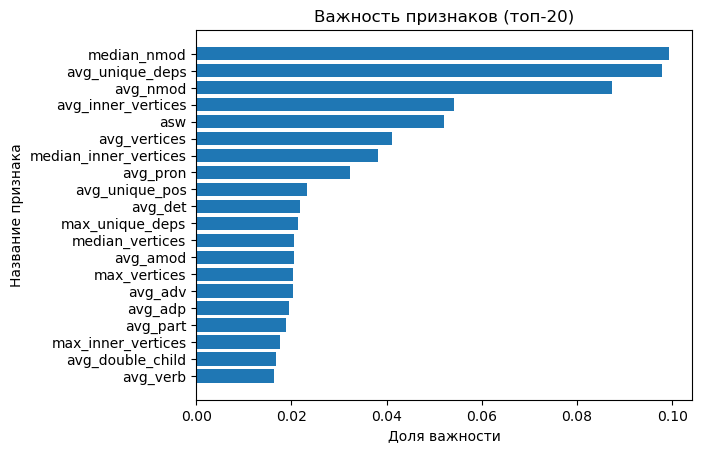

In [874]:
import matplotlib.pyplot as plt

importances = model_best.feature_importances_

feature_names = feats_table_final.drop(columns=["text", "complexity"]).columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp = feat_imp.sort_values(by='importance', ascending=False)

print(feat_imp.head(20))

plt.figure()
plt.barh(feat_imp['feature'][:20], feat_imp['importance'][:20])
plt.gca().invert_yaxis()
plt.title("Важность признаков (топ-20)")
plt.xlabel("Доля важности")
plt.ylabel("Название признака")
plt.show()

### Сравнение разных типов признаков

In [797]:
structure_features = ["length", "avg_vertices", "asw"]
syntax_features = [
                    "avg_double_child", 
                    "avg_inner_vertices", 
                    "avg_tree_depth", 
                    "avg_amod", 
                    "avg_compound",
                    "avg_conj",
                    "avg_det",
                    "avg_nmod",
                    "avg_nsubj",
                    "avg_unique_deps",
                    "max_leaves",
                    "max_inner_vertices",
                    "max_vertices",
                    "max_unique_deps",
                    "median_nmod",
                    "median_inner_vertices",
                    "median_vertices",
                    "std_leaves",
                    "std_vertices",
                    "std_conj",
                    "std_det",
                    "std_mean_linear_distance"]
morph_features = [
                    "avg_adj",
                    "avg_adp",
                    "avg_adv",
                    "avg_aux",
                    "avg_cconj",
                    "avg_det_pos",
                    "avg_intj",
                    "avg_noun",
                    "avg_num",
                    "avg_part",
                    "avg_pron",
                    "avg_propn",
                    "avg_sconj",
                    "avg_verb",
                    "avg_unique_pos",
                    "max_unique_pos"
]
                    

In [817]:
def train_and_evaluate(X_subset, y):
    X_train, X_test, y_train, y_test = train_test_split(X_subset, y, test_size=0.2, random_state=52)
    
    depth_list = [1, 2, 5, 10]
    max_leaf_list = [1, 2, 5, 7]
    learning_rate_list = [0.05, 0.1, 0.2, 0.4, 0.8, 1]
    lambda_list = [1, 5, 10, 20, 40]

    best_model_params = [1, 1, 0.05, 1]
    best_accuracy = 0.1
    model_best = None

    random.seed(2025)
    np.random.seed(2025)
    etap = 0
    for depth in depth_list:
        for lr in learning_rate_list:
            for lambda_ in lambda_list:
                for max_leaf in max_leaf_list:
                    etap +=1
                    model_new = xgb.XGBClassifier(n_estimators = 200, random_state = 52, max_depth=depth, max_leaves=max_leaf, learning_rate = lr, reg_lambda = lambda_)
                    model_new.fit(X_train, y_train)
                    preds_new = model_new.predict(X_test)
                    accuracy_new = accuracy_score(y_test, preds_new)
                    if accuracy_new > best_accuracy:
                        best_model_params = [depth, lr, lambda_, max_leaf]
                        best_accuracy = accuracy_new
                        model_best = model_new

    best_depth = best_model_params[0]
    best_lr = best_model_params[1]
    best_lambda = best_model_params[2]
    best_max_leaf = best_model_params[3]

    model_best = xgb.XGBClassifier(n_estimators = 200, 
                          random_state = 52, 
                          max_depth=best_depth, 
                          max_leaves=best_max_leaf, 
                          learning_rate = best_lr,
                          reg_lambda = best_lambda)


    model_best.fit(X_train, y_train)

    y_pred = model_best.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    return acc, mse, rmse

In [821]:
results = {}

print("Fitting structure only")
results['structure_only'] = train_and_evaluate(feats_overall[structure_features], y)
print("Fitting structure + morph")
results["structure + morph"] = train_and_evaluate(feats_overall[structure_features + morph_features], y)
print("Fitting morph only")
results['morph_only'] = train_and_evaluate(feats_overall[morph_features], y)
print("Fitting morph + syntax")
results['morph + syntax'] = train_and_evaluate(feats_overall[morph_features + syntax_features], y)
print("Fitting syntax only")
results['syntax_only'] = train_and_evaluate(feats_overall[syntax_features], y)
print("Fitting syntax + structure")
results['syntax + structure'] = train_and_evaluate(feats_overall[syntax_features + structure_features], y)
print("Fitting all features")
results['all_features'] = train_and_evaluate(feats_overall[feature_names], y)

Fitting structure only
Fitting structure + morph
Fitting morph only
Fitting morph + syntax
Fitting syntax only
Fitting syntax + structure
Fitting all features
structure_only (0.3735354927636113, 1.4438318401102688, 1.201595539318563)
structure + morph (0.4107512060647829, 1.4203997243280497, 1.191805237582068)
morph_only (0.3728463128876637, 1.6237077877325983, 1.2742479302445808)
morph + syntax (0.39421088904204, 1.545830461750517, 1.24331430529473)
syntax_only (0.36595451412818747, 1.512749827705031, 1.229938952836697)
syntax + structure (0.39352170916609236, 1.39421088904204, 1.1807670765405174)
all_features (0.4169538249483115, 1.3535492763611303, 1.163421366642856)


In [823]:
for k, v in results.items():
    print(f"{k}: accuracy: {v[0]}, mse: {v[1]}, rmse: {v[2]}")

structure_only: accuracy: 0.3735354927636113, mse: 1.4438318401102688, rmse: 1.201595539318563
structure + morph: accuracy: 0.4107512060647829, mse: 1.4203997243280497, rmse: 1.191805237582068
morph_only: accuracy: 0.3728463128876637, mse: 1.6237077877325983, rmse: 1.2742479302445808
morph + syntax: accuracy: 0.39421088904204, mse: 1.545830461750517, rmse: 1.24331430529473
syntax_only: accuracy: 0.36595451412818747, mse: 1.512749827705031, rmse: 1.229938952836697
syntax + structure: accuracy: 0.39352170916609236, mse: 1.39421088904204, rmse: 1.1807670765405174
all_features: accuracy: 0.4169538249483115, mse: 1.3535492763611303, rmse: 1.163421366642856
